<h3 style="color: #e0e0ff; font-style: italic;">🔬 Multimodal Traditional Fusion Strategies for Fake News Detection</h3>

---

**Objective:** Benchmark traditional feature-level and decision-level fusion strategies for combining text (claim) and image features to predict fake news using classical machine learning classifiers.

**Fusion strategies implemented:**

| # | Strategy | Formula | Key Idea | Reference |
|---|----------|---------|----------|-----------|
| 1 | **Early Fusion** | `[img, text]` → clf | Concatenate raw feature vectors | Atrey et al., 2010 |
| 2 | **Late Fusion** | `avg(clf_img(img), clf_text(text))` | Average independent probability predictions | Kittler et al., 1998 |
| 3 | **Ensemble Fusion** | `avg(clf_fused(fused), clf_img(img), clf_text(text))` | Weighted ensemble of fused and unimodal predictions | Wolpert, 1992 |
| 4 | **Bilinear Pooling** | `img ⊗ text` → clf | Capture multiplicative feature-pair interactions | Fukui et al., 2016 |
| 5 | **Metadata-augmented Fusion** | `[img, text, meta]` → clf | Concatenate visual + textual embeddings with structured metadata | Qian et al., 2021 |

**Libraries and Setup**

In [1]:
# Core
import os
import sys
import subprocess
import pickle
import json
from PIL import Image
from tqdm.auto import tqdm
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning & Encoders
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel

# Classical ML Classifiers & Metrics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, precision_recall_fscore_support
)

import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath("../../src"))
from data_pipeline import M4FCDataPipeline
from model_registry import update_registry

c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.facecolor': 'white', 'figure.dpi': 120, 'savefig.dpi': 300})

In [3]:
# Directories
os.makedirs('../../models/fusion', exist_ok=True)
os.makedirs('../../reports/fusion', exist_ok=True)
os.makedirs('../../data/predictions', exist_ok=True)

In [4]:
# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Device: {device}")

🚀 Device: cuda


In [5]:
try:
    import clip
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "git+https://github.com/openai/CLIP.git", "--quiet"])
    import clip

print(f"✅ CLIP version loaded: {clip.__file__}")

✅ CLIP version loaded: c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\venv_ai\Lib\site-packages\clip\__init__.py


**📦 Loading Dataset**

In [6]:
pipeline = M4FCDataPipeline(
    csv_path="../../data/M4FC.csv",
    target_col="target",
    random_state=42,
    normalize=True,
)
df = pipeline._load_data()
print(f"✅ Loaded {len(df):,} samples")
print(f"📊 Target distribution:\n{df['target'].value_counts()}")
print(f"🖼️ Images found: {df['image_exists'].sum()}/{len(df)}")
df.head(3)

✅ Loaded 4,948 samples
📊 Target distribution:
target
1    4656
0     292
Name: count, dtype: int64
🖼️ Images found: 4948/4948


,image_path,image_url,article_url,fc_org,fc_pub_date,fc_language,fc_country,verification_strategy,verification_tools,claim,...,negative_coordinates,is_manipulated_fake,verdict_coarse,multilingual_true_caption,task_verdict_prediction,wayback_image_url,full_image_path,image_exists,claim_word_count,target
0,images/الأرانب-تلد-ولا-تبيض-وصور-هذا-البيض-لا-...,https://cdn4.fatabyyano.net/wp-content/uploads...,https://fatabyyano.net/الأرانب-تلد-ولا-تبيض-وص...,fatabyyano.net,2021-12-19 19:36:09,arabic,Jordan,reverse image search,google,Rabbits lay eggs,...,not enough information,False,False,not enough information,True,https://web.archive.org/web/20220404045630/htt...,..\..\M4FC\data_wayback\images\الأرانب-تلد-ولا...,True,3,1
1,images/الشاب-الذي-يظهر-في-الصورة-من-مصر-وهو-ما...,https://cdn4.fatabyyano.net/wp-content/uploads...,https://fatabyyano.net/الشاب-الذي-يظهر-في-الصو...,fatabyyano.net,2021-03-07 16:57:55,arabic,Jordan,reverse image search,not enough information,The young man is from Syria and has committed ...,...,not enough information,False,False,not enough information,True,https://web.archive.org/web/20251019124008/htt...,..\..\M4FC\data_wayback\images\الشاب-الذي-يظهر...,True,10,1
2,images/الصور-تعود-إلى-مبادرة-في-العراق-ليس-الأ...,https://cdn4.fatabyyano.net/wp-content/uploads...,https://fatabyyano.net/%D8%A7%D9%84%D8%B5%D9%8...,fatabyyano.net,2021-01-11 23:30:26,arabic,Jordan,keyword search,google,A new and beautiful initiative in Jordan.,...,not enough information,False,False,يشارك المتطوعون العراقيون في مبادرة الدفء في ك...,True,https://web.archive.org/web/20250101163221/htt...,..\..\M4FC\data_wayback\images\الصور-تعود-إلى-...,True,7,1


**🧠 Feature Extractors**

We use **CLIP** (ViT-B/16) for images and **XLM-RoBERTa** (base) for multilingual text. Both produce 768-dim embeddings respectively. We freeze them and extract features once to keep training fast.

* **`ViT-B/16`** — A specific Vision Transformer model where "B" stands for Base (size), and "/16" means it splits images into 16x16 pixel patches before processing them.
* **`XLM-RoBERTa`** — A multilingual version of RoBERTa trained on **100 languages**, designed to understand **cross-lingual text** (e.g., classify or translate without needing separate models per language).

How CLIP works in brief:

1.  **Image** → ViT (or ResNet) → Image embedding
2.  **Text** → Transformer → Text embedding
3.  **Project** both to the **same dimension** (unified space)
4.  **Normalize** both embeddings (unit length)
5.  **Compute cosine similarity** (dot product of normalized vectors)

**The training goal:** Maximize similarity for matching (image, text) pairs, minimize for non-matching pairs.

**🔄 Feature Extraction Pipeline**

Extract frozen embeddings once and cache to disk. This avoids recomputing on every experiment.

In [7]:
# --------------------- IMAGE ENCODER ---------------------
class ImageEncoder(nn.Module): # To turn images into feature vectors
    def __init__(self, output_dim=768, freeze=True):
        super().__init__()
        self.clip_model, self.preprocess = clip.load("ViT-B/16", device=device)
        self.output_dim = output_dim
        if freeze:
            for param in self.clip_model.visual.parameters():
                param.requires_grad = False

    def forward(self, x):
        return self.clip_model.encode_image(x).float()

In [8]:
# --------------------- TEXT ENCODER ---------------------
class TextEncoder(nn.Module): # Converts text into feature vectors
    def __init__(self, model_name="xlm-roberta-base", output_dim=768, freeze=True):
        super().__init__()
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(device)
        self.output_dim = output_dim
        if freeze:
            for param in self.model.parameters():
                param.requires_grad = False

    def forward(self, text, max_length=128):
        tokens = self.tokenizer(
            text, padding=True, truncation=True, max_length=max_length, return_tensors="pt"
        )
        tokens = {k: v.to(device) for k, v in tokens.items()}
        with torch.no_grad(): # turns off gradient tracking
            outputs = self.model(**tokens)
        return outputs.last_hidden_state[:, 0, :] # CLS token is the summary

In [9]:
CACHE_DIR = '../../data/features'
os.makedirs(CACHE_DIR, exist_ok=True)

In [10]:
def extract_and_cache(df, force_recompute=False): # Uses cached outputs if available, don't recompute
    img_cache = os.path.join(CACHE_DIR, 'image_features_vit16.pt')
    text_cache = os.path.join(CACHE_DIR, 'text_features_vit16.pt')
    label_cache = os.path.join(CACHE_DIR, 'labels_vit16.pt')
    
    if not force_recompute and all(os.path.exists(f) for f in [img_cache, text_cache, label_cache]):
        print("📂 Loading cached features...")
        img_feats = torch.load(img_cache)
        text_feats = torch.load(text_cache)
        labels = torch.load(label_cache)
        print(f"   ✅ Image features: {img_feats.shape}")
        print(f"   ✅ Text features:  {text_feats.shape}")
        print(f"   ✅ Labels:         {len(labels)}")
        return img_feats, text_feats, labels

    print("🔄 Extracting features (this may take a while)...")
    img_encoder = ImageEncoder().to(device).eval()
    text_encoder = TextEncoder().to(device).eval()
    
    img_feats_list, text_feats_list, labels_list = [], [], []
    preprocess = img_encoder.preprocess # CLIP's image transforms (resize, normalize, etc.) from the encoder instance
    
    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting"):
        # Image
        if row['image_exists']:
            try:
                # Preprocessing before encoding
                img = preprocess(Image.open(row['full_image_path']).convert("RGB")).unsqueeze(0).to(device)
                with torch.no_grad(): # Disables gradient tracking (faster, less memory)
                    img_feat = img_encoder(img).cpu()
            except:
                img_feat = torch.zeros(1, img_encoder.output_dim)
        else:
            img_feat = torch.zeros(1, img_encoder.output_dim)
        
        # Text
        text_feat = text_encoder([row['multilingual_claim']]).cpu()
        
        img_feats_list.append(img_feat)
        text_feats_list.append(text_feat)
        labels_list.append(row['target'])
    
    img_feats = torch.cat(img_feats_list, dim=0)
    text_feats = torch.cat(text_feats_list, dim=0)
    labels = torch.tensor(labels_list, dtype=torch.long)
    
    torch.save(img_feats, img_cache)
    torch.save(text_feats, text_cache)
    torch.save(labels, label_cache)
    print(f"   ✅ Cached to {CACHE_DIR}/")
    return img_feats, text_feats, labels

In [11]:
img_feats, text_feats, labels = extract_and_cache(df)

📂 Loading cached features...
   ✅ Image features: torch.Size([4948, 512])
   ✅ Text features:  torch.Size([4948, 768])
   ✅ Labels:         4948


**📊 Train/Val/Test Split**

In [12]:
min_len = min(len(img_feats), len(df))
img_feats = img_feats[:min_len]
text_feats = text_feats[:min_len]
labels = labels[:min_len]

In [13]:
tensors = pipeline.split_and_resample_tensors(img_feats, text_feats, labels)

train_idx = list(tensors["idx_train"])
val_idx = list(tensors["idx_val"])
test_idx = list(tensors["idx_test"])

X_img_train = tensors["img_train"].numpy()
X_img_val = tensors["img_val"].numpy()
X_img_test = tensors["img_test"].numpy()

X_text_train = tensors["txt_train"].numpy()
X_text_val = tensors["txt_val"].numpy()
X_text_test = tensors["txt_test"].numpy()

y_train = tensors["y_train"].numpy()
y_val = tensors["y_val"].numpy()
y_test = tensors["y_test"].numpy()

✂️  Tensor split completed → train=3,462 | val=743 | test=743


In [14]:
print("📊 Split sizes:")
print(f"   Train: {len(y_train):,}  |  Val: {len(y_val):,}  |  Test: {len(y_test):,}")
print(f"   Train balance: {np.bincount(y_train)}")
print(f"   Val balance:   {np.bincount(y_val)}")
print(f"   Test balance:  {np.bincount(y_test)}")

📊 Split sizes:
   Train: 3,462  |  Val: 743  |  Test: 743
   Train balance: [ 204 3258]
   Val balance:   [ 44 699]
   Test balance:  [ 44 699]


**Regularized Configurations (to prevent overfitting)**

In [15]:
REDUCED_CONFIGS = {
    'rf': {'n_estimators': 30, 'max_depth': 3, 'min_samples_split': 20, 
           'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced'},
    'gb': {'n_estimators': 30, 'max_depth': 2, 'learning_rate': 0.01, 
           'subsample': 0.5, 'min_samples_split': 20},
    'svm': {'kernel': 'linear', 'C': 0.01, 'probability': True,
            'class_weight': 'balanced', 'max_iter': 1000},
    'mlp': {'hidden_layer_sizes': (32, 16), 'max_iter': 150, 
            'alpha': 0.1, 'batch_size': 16, 'early_stopping': True, 'validation_fraction': 0.1}, # Alpha : Adds a penalty for large weights to prevent overfitting
    'logreg': {'max_iter': 1000, 'C': 0.01, 'penalty': 'l2', 'class_weight': 'balanced'
               }
}

In [16]:
# --------------- Evaluation Function ---------------
def evaluate_model(name, model, X_img_test, X_text_test, y_test, metadata=None):
    if metadata is not None:
        y_pred = model.predict(X_img_test, X_text_test, metadata=metadata)
        y_proba = model.predict_proba(X_img_test, X_text_test, metadata=metadata)[:, 1]
    else:
        y_pred = model.predict(X_img_test, X_text_test)
        y_proba = model.predict_proba(X_img_test, X_text_test)[:, 1]
    
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba)
    }
    return metrics


**🔗 Strategy 1: Early Fusion (Feature Concatenation)**

Concatenate image and text features into a single vector, then classify.

In [17]:
class EarlyFusionClassifier:
    def __init__(self, clf_type='logreg'):
        if clf_type == 'logreg':
            self.clf = LogisticRegression(**REDUCED_CONFIGS['logreg'])
        elif clf_type == 'rf':
            self.clf = RandomForestClassifier(**REDUCED_CONFIGS['rf'])
        elif clf_type == 'gb':
            self.clf = GradientBoostingClassifier(**REDUCED_CONFIGS['gb'])
        elif clf_type == 'svm':
            self.clf = SVC(**REDUCED_CONFIGS['svm'])
        elif clf_type == 'mlp':
            self.clf = MLPClassifier(**REDUCED_CONFIGS['mlp'])
        self.scaler = StandardScaler()
        self.clf_type = clf_type
        
    def fit(self, X_img, X_text, y):
        X_concat = np.concatenate([X_img, X_text], axis=1)
        X_scaled = self.scaler.fit_transform(X_concat)
        self.clf.fit(X_scaled, y)
        return self
        
    def predict(self, X_img, X_text):
        X_concat = np.concatenate([X_img, X_text], axis=1)
        X_scaled = self.scaler.transform(X_concat)
        return self.clf.predict(X_scaled)
    
    def predict_proba(self, X_img, X_text):
        X_concat = np.concatenate([X_img, X_text], axis=1)
        X_scaled = self.scaler.transform(X_concat)
        return self.clf.predict_proba(X_scaled)

In [18]:
# --------------- Training ---------------
results = []

for clf_name in ['logreg', 'rf', 'gb', 'svm', 'mlp']:  
    print(f"\n{'='*50}")
    print(f"🔹 Early Fusion + {clf_name.upper()}")
    print(f"{'='*50}")
    
    model = EarlyFusionClassifier(clf_type=clf_name)
    model.fit(X_img_train, X_text_train, y_train)
    
    # Val metrics
    y_val_pred = model.predict(X_img_val, X_text_val)
    y_val_proba = model.predict_proba(X_img_val, X_text_val)[:, 1]
    print(f"   Val Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
    print(f"   Val F1:       {f1_score(y_val, y_val_pred):.4f}")
    
    metrics = evaluate_model(f'Early Fusion ({clf_name.upper()})', model, X_img_test, X_text_test, y_test)
    results.append(metrics)

print(f"\n{'='*50}")
print("✅ Early Fusion Complete")


🔹 Early Fusion + LOGREG


   Val Accuracy: 0.9058
   Val F1:       0.9484

🔹 Early Fusion + RF
   Val Accuracy: 0.8412
   Val F1:       0.9091

🔹 Early Fusion + GB
   Val Accuracy: 0.9408
   Val F1:       0.9695

🔹 Early Fusion + SVM
   Val Accuracy: 0.9246
   Val F1:       0.9597

🔹 Early Fusion + MLP
   Val Accuracy: 0.9408
   Val F1:       0.9693

✅ Early Fusion Complete


**🔗 Strategy 2: Late Fusion (Decision-Level)**

Train separate unimodal classifiers on image-only and text-only features, then average their predicted probabilities.

In [19]:
# --------------- LATE FUSION CLASSIFIER ---------------
class LateFusionClassifier:
    def __init__(self, clf_type='logreg'):
        self.clf_type = clf_type
        self.img_clf = None
        self.text_clf = None
        self.img_scaler = StandardScaler()
        self.text_scaler = StandardScaler()
        
    def _get_clf(self):
        if self.clf_type == 'logreg':
            return LogisticRegression(**REDUCED_CONFIGS['logreg'])
        elif self.clf_type == 'rf':
            return RandomForestClassifier(**REDUCED_CONFIGS['rf'])
        elif self.clf_type == 'gb':
            return GradientBoostingClassifier(**REDUCED_CONFIGS['gb'])
        elif self.clf_type == 'svm':
            return SVC(**REDUCED_CONFIGS['svm'])
        elif self.clf_type == 'mlp':
            return MLPClassifier(**REDUCED_CONFIGS['mlp'])
        
    def fit(self, X_img, X_text, y):
        self.img_clf = self._get_clf()
        self.text_clf = self._get_clf()
        
        X_img_scaled = self.img_scaler.fit_transform(X_img)
        X_text_scaled = self.text_scaler.fit_transform(X_text)
        
        self.img_clf.fit(X_img_scaled, y)
        self.text_clf.fit(X_text_scaled, y)
        return self
        
    def predict(self, X_img, X_text):
        proba = self.predict_proba(X_img, X_text)
        return proba.argmax(axis=1) 
    
    def predict_proba(self, X_img, X_text):
        X_img_scaled = self.img_scaler.transform(X_img)
        X_text_scaled = self.text_scaler.transform(X_text)
        
        img_proba = self.img_clf.predict_proba(X_img_scaled)
        text_proba = self.text_clf.predict_proba(X_text_scaled)
        
        # Average probabilities
        avg_proba = (img_proba + text_proba) / 2.0
        return avg_proba

In [20]:
# --------------- Training ---------------
for clf_name in ['logreg', 'rf', 'gb', 'svm', 'mlp']:
    print(f"\n{'='*50}")
    print(f"🔹 Late Fusion + {clf_name.upper()}")
    print(f"{'='*50}")
    
    model = LateFusionClassifier(clf_type=clf_name)
    model.fit(X_img_train, X_text_train, y_train)
    
    y_val_pred = model.predict(X_img_val, X_text_val)
    print(f"   Val Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
    print(f"   Val F1:       {f1_score(y_val, y_val_pred):.4f}")
    
    metrics = evaluate_model(f'Late Fusion ({clf_name.upper()})', model, X_img_test, X_text_test, y_test)
    results.append(metrics)

print(f"\n{'='*50}")
print("✅ Late Fusion Complete")


🔹 Late Fusion + LOGREG


   Val Accuracy: 0.8923
   Val F1:       0.9405

🔹 Late Fusion + RF
   Val Accuracy: 0.8641
   Val F1:       0.9232

🔹 Late Fusion + GB
   Val Accuracy: 0.9408
   Val F1:       0.9695

🔹 Late Fusion + SVM
   Val Accuracy: 0.9408
   Val F1:       0.9695

🔹 Late Fusion + MLP
   Val Accuracy: 0.9421
   Val F1:       0.9702

✅ Late Fusion Complete


**🔗 Strategy 3: Ensemble Fusion**

Ensemble Fusion = averaging (or combining) the outputs of early fusion and late fusion.

Three-way ensemble:

- Mid-level (early) fusion → 50% weight

- Image-only classifier → 25% weight

- Text-only classifier → 25% weight

In [21]:
# --------------- ENSEMBLE FUSION CLASSIFIER ---------------
class EnsembleFusionClassifier:
    def __init__(self, clf_type='logreg', fusion_dim=256):
        self.clf_type = clf_type
        self.fusion_dim = fusion_dim
        self.img_proj = None  
        self.text_proj = None

        self.mid_clf = None
        self.img_clf = None
        self.text_clf = None
        self.scaler = StandardScaler()
        
    def _get_clf(self):
        if self.clf_type == 'logreg':
            return LogisticRegression(**REDUCED_CONFIGS['logreg'])
        elif self.clf_type == 'rf':
            return RandomForestClassifier(**REDUCED_CONFIGS['rf'])
        elif self.clf_type == 'gb':
            return GradientBoostingClassifier(**REDUCED_CONFIGS['gb'])
        elif self.clf_type == 'svm':
            return SVC(**REDUCED_CONFIGS['svm'])
        elif self.clf_type == 'mlp':
            return MLPClassifier(**REDUCED_CONFIGS['mlp'])
        
    def fit(self, X_img, X_text, y):
        # --- Mid-level projection (PCA with regularization) ---
        # Smaller fusion_dim to prevent overfitting 
        actual_fusion_dim = min(self.fusion_dim, 128, X_img.shape[1] // 2)
        self.img_proj = PCA(n_components=actual_fusion_dim, random_state=42)
        self.text_proj = PCA(n_components=actual_fusion_dim, random_state=42)
        
        img_projected = self.img_proj.fit_transform(X_img)
        text_projected = self.text_proj.fit_transform(X_text)
        fused = img_projected * text_projected  # Hadamard product
        
        # --- Train mid-level classifier ---
        X_fused_scaled = self.scaler.fit_transform(fused)
        self.mid_clf = self._get_clf()
        self.mid_clf.fit(X_fused_scaled, y)
        
        # --- Train unimodal classifiers ---
        self.img_clf = self._get_clf()
        self.text_clf = self._get_clf()
        self.img_clf.fit(X_img, y)
        self.text_clf.fit(X_text, y)
        
        return self
    
    def predict(self, X_img, X_text):
        proba = self.predict_proba(X_img, X_text)
        return proba.argmax(axis=1) 

    def predict_proba(self, X_img, X_text):
        # Mid-level fused prediction
        img_projected = self.img_proj.transform(X_img)
        text_projected = self.text_proj.transform(X_text)
        fused = img_projected * text_projected
        fused_scaled = self.scaler.transform(fused)
        mid_proba = self.mid_clf.predict_proba(fused_scaled)
        
        # Unimodal predictions
        img_proba = self.img_clf.predict_proba(X_img)
        text_proba = self.text_clf.predict_proba(X_text)
        
        # Hybrid combination: weighted average
        hybrid_proba = (mid_proba * 0.5 + img_proba * 0.25 + text_proba * 0.25)
        return hybrid_proba

In [22]:
# --------------- Training ---------------
for clf_name in ['logreg', 'rf', 'gb', 'svm', 'mlp']:
    print(f"\n{'='*50}")
    print(f"🔹 Ensemble Fusion + {clf_name.upper()}")
    print(f"{'='*50}")
    
    model = EnsembleFusionClassifier(clf_type=clf_name)
    model.fit(X_img_train, X_text_train, y_train)
    
    y_val_pred = model.predict(X_img_val, X_text_val)
    print(f"   Val Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
    print(f"   Val F1:       {f1_score(y_val, y_val_pred):.4f}")
    
    metrics = evaluate_model(f'Hybrid Fusion ({clf_name.upper()})', model, X_img_test, X_text_test, y_test)
    results.append(metrics)

print(f"\n{'='*50}")
print("✅ Ensemble Fusion Complete")


🔹 Ensemble Fusion + LOGREG
   Val Accuracy: 0.8560
   Val F1:       0.9186

🔹 Ensemble Fusion + RF
   Val Accuracy: 0.8600
   Val F1:       0.9212

🔹 Ensemble Fusion + GB
   Val Accuracy: 0.9408
   Val F1:       0.9695

🔹 Ensemble Fusion + SVM
   Val Accuracy: 0.9408
   Val F1:       0.9695

🔹 Ensemble Fusion + MLP
   Val Accuracy: 0.9408
   Val F1:       0.9695

✅ Ensemble Fusion Complete


**🔗 Strategy 4: Bilinear Pooling (Outer Product Interaction)**

Compute outer product between image and text features, then aggregate via sum pooling. Captures multiplicative interactions between all feature pairs.

In [23]:
# --------------- BILINEAR POOLING CLASSIFIER ---------------
class BilinearPoolingClassifier:
    def __init__(self, clf_type='logreg', rank=32): 
        self.clf_type = clf_type
        self.rank = rank
        self.img_proj = None
        self.text_proj = None
        self.clf = None
        self.scaler = StandardScaler()
        
    def _get_clf(self):
        if self.clf_type == 'logreg':
            return LogisticRegression(**REDUCED_CONFIGS['logreg'])
        elif self.clf_type == 'rf':
            return RandomForestClassifier(**REDUCED_CONFIGS['rf'])
        elif self.clf_type == 'gb':
            return GradientBoostingClassifier(**REDUCED_CONFIGS['gb'])
        elif self.clf_type == 'svm':
            return SVC(**REDUCED_CONFIGS['svm'])
        elif self.clf_type == 'mlp':
            return MLPClassifier(**REDUCED_CONFIGS['mlp'])
        
    def fit(self, X_img, X_text, y):
        # Reduce dimensions for tractable bilinear interaction
        # Smaller rank to prevent overfitting
        actual_rank = min(self.rank, 32, X_img.shape[1] // 4)
        self.img_proj = PCA(n_components=actual_rank, random_state=42)
        self.text_proj = PCA(n_components=actual_rank, random_state=42)
        
        img_low = self.img_proj.fit_transform(X_img)     
        text_low = self.text_proj.fit_transform(X_text)    
        
        # Bilinear pooling: outer product per sample
        img_exp = img_low[:, :, np.newaxis]                # (N, rank, 1)
        text_exp = text_low[:, np.newaxis, :]               # (N, 1, rank)
        bilinear = (img_exp * text_exp).reshape(len(img_low), -1)  # (N, rank*rank)
        
        # Power normalization (signed square root) to reduce outliers
        bilinear = np.sign(bilinear) * np.sqrt(np.abs(bilinear))
        
        X_fused = bilinear  
        
        # Apply L2 normalization
        X_fused = X_fused / (np.linalg.norm(X_fused, axis=1, keepdims=True) + 1e-8)
        
        X_scaled = self.scaler.fit_transform(X_fused)
        
        self.clf = self._get_clf()
        self.clf.fit(X_scaled, y)
        return self

    def predict(self, X_img, X_text):
        proba = self.predict_proba(X_img, X_text)
        return (proba[:, 1] >= 0.5).astype(int) 
    
    def predict_proba(self, X_img, X_text):
        img_low = self.img_proj.transform(X_img)
        text_low = self.text_proj.transform(X_text)
        
        img_exp = img_low[:, :, np.newaxis]
        text_exp = text_low[:, np.newaxis, :]
        bilinear = (img_exp * text_exp).reshape(len(img_low), -1)
        
        bilinear = np.sign(bilinear) * np.sqrt(np.abs(bilinear))
        X_fused = bilinear
        X_fused = X_fused / (np.linalg.norm(X_fused, axis=1, keepdims=True) + 1e-8)
        X_scaled = self.scaler.transform(X_fused)
        
        return self.clf.predict_proba(X_scaled)

In [24]:
# --------------- Training ---------------
for clf_name in ['logreg', 'rf', 'gb', 'svm', 'mlp']:
    print(f"\n{'='*50}")
    print(f"🔹 Bilinear Pooling + {clf_name.upper()}")
    print(f"{'='*50}")
    
    model = BilinearPoolingClassifier(clf_type=clf_name)
    model.fit(X_img_train, X_text_train, y_train)
    
    y_val_pred = model.predict(X_img_val, X_text_val)
    print(f"   Val Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
    print(f"   Val F1:       {f1_score(y_val, y_val_pred):.4f}")
    
    metrics = evaluate_model(f'Bilinear Pooling ({clf_name.upper()})', model, X_img_test, X_text_test, y_test)
    results.append(metrics)

print(f"\n{'='*50}")
print("✅ Bilinear Pooling Complete")


🔹 Bilinear Pooling + LOGREG
   Val Accuracy: 0.8250
   Val F1:       0.8992

🔹 Bilinear Pooling + RF
   Val Accuracy: 0.7927
   Val F1:       0.8780

🔹 Bilinear Pooling + GB
   Val Accuracy: 0.9408
   Val F1:       0.9695

🔹 Bilinear Pooling + SVM
   Val Accuracy: 0.9408
   Val F1:       0.9695

🔹 Bilinear Pooling + MLP
   Val Accuracy: 0.9448
   Val F1:       0.9713

✅ Bilinear Pooling Complete


**🔗 Strategy 5: Metadata-augmented Fusion**

In [25]:
# --------------- METADATA-AUGMENTED FUSION ---------------
class MetadataAugmentedFusion:
    """
    Metadata: is_ai_generated, image_exists, claim_word_count, 
              is_manipulated_fake, use_true_caption
    """
    def __init__(self, clf_type='logreg', use_metadata=True):
        self.clf_type = clf_type
        self.use_metadata = use_metadata
        self.clf = None
        self.scaler = StandardScaler()
        
    def _get_clf(self):
        if self.clf_type == 'logreg':
            return LogisticRegression(**REDUCED_CONFIGS['logreg'])
        elif self.clf_type == 'rf':
            return RandomForestClassifier(**REDUCED_CONFIGS['rf'])
        elif self.clf_type == 'gb':
            return GradientBoostingClassifier(**REDUCED_CONFIGS['gb'])
        elif self.clf_type == 'svm':
            return SVC(**REDUCED_CONFIGS['svm'])
        elif self.clf_type == 'mlp':
            return MLPClassifier(**REDUCED_CONFIGS['mlp'])
    
    def _extract_metadata_features(self, df_split):
        """Extract metadata features from dataframe split"""
        metadata_columns = ['is_ai_generated', 'image_exists', 'claim_word_count', 
                            'is_manipulated_fake', 'use_true_caption']
        metadata_raw = df_split[metadata_columns].fillna(0).values
        metadata_normalized = np.zeros_like(metadata_raw, dtype=float)
        for i, col in enumerate(metadata_columns):
            if col == 'claim_word_count':
                metadata_normalized[:, i] = metadata_raw[:, i] / 100.0
            else: 
                metadata_normalized[:, i] = metadata_raw[:, i]
        return metadata_normalized
    
    def fit(self, X_img, X_text, y, metadata=None):
        if self.use_metadata and metadata is not None:
            X_fused = np.concatenate([X_img, X_text, metadata], axis=1)
        elif self.use_metadata:
            print("⚠️ Metadata not provided, using zeros")
            metadata = np.zeros((len(X_img), 5))
            X_fused = np.concatenate([X_img, X_text, metadata], axis=1)
        else:
            X_fused = np.concatenate([X_img, X_text], axis=1)
        
        X_scaled = self.scaler.fit_transform(X_fused)
        self.clf = self._get_clf()
        self.clf.fit(X_scaled, y)
        return self
    
    def predict(self, X_img, X_text, metadata=None):
        proba = self.predict_proba(X_img, X_text, metadata)
        return (proba[:, 1] >= 0.5).astype(int)
    
    def predict_proba(self, X_img, X_text, metadata=None):
        if self.use_metadata and metadata is not None:
            X_fused = np.concatenate([X_img, X_text, metadata], axis=1)
        elif self.use_metadata:
            metadata = np.zeros((len(X_img), 5))
            X_fused = np.concatenate([X_img, X_text, metadata], axis=1)
        else:
            X_fused = np.concatenate([X_img, X_text], axis=1)
        
        X_scaled = self.scaler.transform(X_fused)
        return self.clf.predict_proba(X_scaled)


# Extract metadata from dataframe for all samples
print("\n📊 Extracting metadata features...")

# Define metadata columns
metadata_columns = ['is_ai_generated', 'image_exists', 'claim_word_count', 
                    'is_manipulated_fake', 'use_true_caption']

# Normalize metadata
metadata_raw = df[metadata_columns].fillna(0).values
metadata_normalized = np.zeros_like(metadata_raw, dtype=float)

for i, col in enumerate(metadata_columns):
    if col == 'claim_word_count':
        # Normalize word count by 100 (typical max length)
        metadata_normalized[:, i] = metadata_raw[:, i] / 100.0
    else:
        # Binary or already normalized columns
        metadata_normalized[:, i] = metadata_raw[:, i]

print(f"✅ Metadata shape: {metadata_normalized.shape}")
print(f"   Columns: {metadata_columns}")

# Split metadata to match train/val/test indices
metadata_train = metadata_normalized[train_idx]
metadata_val = metadata_normalized[val_idx]
metadata_test = metadata_normalized[test_idx]

print(f"   Metadata train: {metadata_train.shape}, val: {metadata_val.shape}, test: {metadata_test.shape}")


📊 Extracting metadata features...
✅ Metadata shape: (4948, 5)
   Columns: ['is_ai_generated', 'image_exists', 'claim_word_count', 'is_manipulated_fake', 'use_true_caption']
   Metadata train: (3462, 5), val: (743, 5), test: (743, 5)


In [26]:
print("\n" + "="*60)
print("🔹 Metadata-augmented Fusion")
print("="*60)

for clf_name in ['logreg', 'rf', 'gb', 'svm', 'mlp']:
    print(f"\n{'='*50}")
    print(f"🔹 Metadata Fusion + {clf_name.upper()}")
    print(f"{'='*50}")
    
    model = MetadataAugmentedFusion(clf_type=clf_name, use_metadata=True)
    model.fit(X_img_train, X_text_train, y_train, metadata=metadata_train)
    
    y_val_pred = model.predict(X_img_val, X_text_val, metadata=metadata_val)
    print(f"   Val Accuracy: {accuracy_score(y_val, y_val_pred):.4f}")
    print(f"   Val F1:       {f1_score(y_val, y_val_pred):.4f}")
    
    metrics = evaluate_model(
        f'Metadata Fusion ({clf_name.upper()})',
        model,
        X_img_test, X_text_test, y_test,
        metadata=metadata_test
    )
    results.append(metrics)

print(f"\n{'='*50}")
print("✅ Metadata Fusion Complete")



🔹 Metadata-augmented Fusion

🔹 Metadata Fusion + LOGREG


   Val Accuracy: 0.9152
   Val F1:       0.9537

🔹 Metadata Fusion + RF
   Val Accuracy: 0.8843
   Val F1:       0.9354

🔹 Metadata Fusion + GB
   Val Accuracy: 0.9408
   Val F1:       0.9695

🔹 Metadata Fusion + SVM
   Val Accuracy: 0.9341
   Val F1:       0.9659

🔹 Metadata Fusion + MLP
   Val Accuracy: 0.9435
   Val F1:       0.9705

✅ Metadata Fusion Complete


**📊 Results Summary**

Side-by-side comparison of all fusion strategies across classifiers.

In [27]:
df_results = pd.DataFrame(results)

In [28]:
df_results_sorted = df_results.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("🏆 Fusion Strategy Benchmark Results")
print("=" * 80)
display(df_results)


🏆 Fusion Strategy Benchmark Results


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Early Fusion (LOGREG),0.912517,0.983232,0.922747,0.952030,0.887762
1,Early Fusion (RF),0.823688,0.981356,0.828326,0.898371,0.882397
2,Early Fusion (GB),0.940781,0.940781,1.000000,0.969487,0.879487
3,Early Fusion (SVM),0.931359,0.970930,0.955651,0.963230,0.860613
4,Early Fusion (MLP),0.943472,0.951857,0.989986,0.970547,0.892639
5,Late Fusion (LOGREG),0.893674,0.981366,0.904149,0.941176,0.875927
6,Late Fusion (RF),0.849260,0.985124,0.852647,0.914110,0.888770
7,Late Fusion (GB),0.940781,0.940781,1.000000,0.969487,0.880072
8,Late Fusion (SVM),0.940781,0.940781,1.000000,0.969487,0.829562
9,Late Fusion (MLP),0.939435,0.940701,0.998569,0.968772,0.835739


In [29]:
# Highlight winner
best = df_results_sorted.iloc[0]

print("\n" + "="*80)
print(f"🥇 BEST MODEL: {best['Model']}")
print("="*80)
print(f"   Accuracy:  {best['Accuracy']:.4f}")
print(f"   Precision: {best['Precision']:.4f}")
print(f"   Recall:    {best['Recall']:.4f}")
print(f"   F1-Score:  {best['F1-Score']:.4f}")
print(f"   ROC-AUC:   {best['ROC-AUC']:.4f}")


🥇 BEST MODEL: Metadata Fusion (MLP)
   Accuracy:  0.9502
   Precision: 0.9547
   Recall:    0.9943
   F1-Score:  0.9741
   ROC-AUC:   0.9041


In [30]:
# --------------- STRATEGY EXTRACTION ---------------
strategy_names = ['Early Fusion', 'Late Fusion', 'Hybrid Fusion', 
                  'Bilinear Pooling', 'Metadata Fusion']

def get_strategy(model_name):
    for strategy in strategy_names:
        if strategy in model_name:
            return strategy
    return 'Unknown'

df_results['Strategy'] = df_results['Model'].apply(get_strategy)

# Check results
print(f"✅ Strategy column created with {df_results['Strategy'].nunique()} unique strategies")
display(df_results[['Model', 'Strategy']].head(10))

✅ Strategy column created with 5 unique strategies


,Model,Strategy
0,Early Fusion (LOGREG),Early Fusion
1,Early Fusion (RF),Early Fusion
2,Early Fusion (GB),Early Fusion
3,Early Fusion (SVM),Early Fusion
4,Early Fusion (MLP),Early Fusion
5,Late Fusion (LOGREG),Late Fusion
6,Late Fusion (RF),Late Fusion
7,Late Fusion (GB),Late Fusion
8,Late Fusion (SVM),Late Fusion
9,Late Fusion (MLP),Late Fusion


**🧪 Best Model Deep Dive: Confusion Matrix & Per-Class Metrics**

Evaluate the top-performing strategy on the test set in detail.

In [31]:
# Get best model from results
best_model_name = df_results_sorted.iloc[0]['Model']
print(f"🔬 Deep dive: {best_model_name}")

# Parse strategy and classifier from name
strategy_map = {
    'Early Fusion': EarlyFusionClassifier,
    'Late Fusion': LateFusionClassifier,
    'Hybrid Fusion': EnsembleFusionClassifier,
    'Ensemble Fusion': EnsembleFusionClassifier,
    'Bilinear Pooling': BilinearPoolingClassifier,
    'Metadata Fusion': MetadataAugmentedFusion
}
strategy_name = get_strategy(best_model_name)

# Extract classifier type
try:
    clf_type = best_model_name.split('(')[1].split(')')[0].lower()
except IndexError:
    clf_type = 'unknown'

print(f"   Strategy: {strategy_name}")
print(f"   Classifier: {clf_type.upper()}")

# Initialize and train best model
best_model = strategy_map[strategy_name](clf_type=clf_type)
uses_metadata = 'Metadata' in strategy_name

# Train and predict with metadata handling
if uses_metadata:
    best_model.fit(X_img_train, X_text_train, y_train, metadata=metadata_train)
    y_test_pred = best_model.predict(X_img_test, X_text_test, metadata=metadata_test)
    y_test_proba = best_model.predict_proba(X_img_test, X_text_test, metadata=metadata_test)[:, 1]
else:
    best_model.fit(X_img_train, X_text_train, y_train)
    y_test_pred = best_model.predict(X_img_test, X_text_test)
    y_test_proba = best_model.predict_proba(X_img_test, X_text_test)[:, 1]
    
# Classification Report
print("\n📋 Classification Report (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Legitimate', 'Fake/Misleading']))

# Per-class metrics
precision_class, recall_class, f1_class, _ = precision_recall_fscore_support(y_test, y_test_pred)
print("\n📊 Per-Class Metrics:")
print(f"   Legitimate     - Precision: {precision_class[0]:.4f}, Recall: {recall_class[0]:.4f}, F1: {f1_class[0]:.4f}")
print(f"   Fake/Misleading - Precision: {precision_class[1]:.4f}, Recall: {recall_class[1]:.4f}, F1: {f1_class[1]:.4f}")

🔬 Deep dive: Metadata Fusion (MLP)
   Strategy: Metadata Fusion
   Classifier: MLP



📋 Classification Report (Test Set):
                 precision    recall  f1-score   support

     Legitimate       0.74      0.45      0.56        44
Fake/Misleading       0.97      0.99      0.98       699

       accuracy                           0.96       743
      macro avg       0.85      0.72      0.77       743
   weighted avg       0.95      0.96      0.95       743


📊 Per-Class Metrics:
   Legitimate     - Precision: 0.7407, Recall: 0.4545, F1: 0.5634
   Fake/Misleading - Precision: 0.9665, Recall: 0.9900, F1: 0.9781


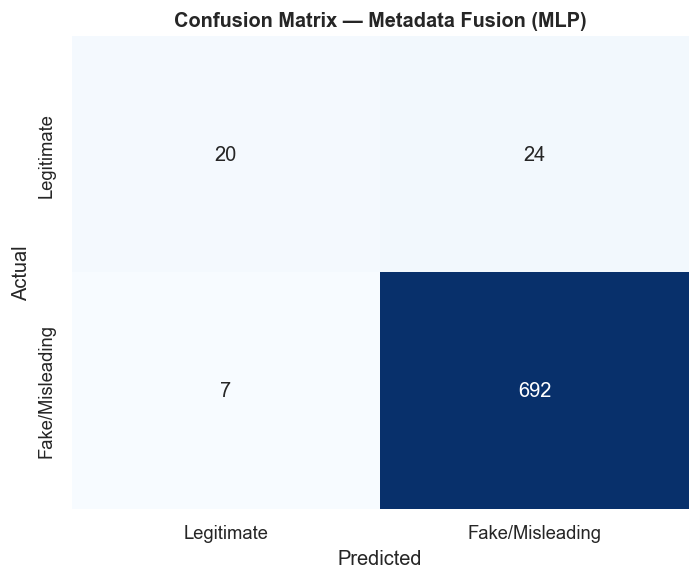

In [32]:
# --------------- CONFUSION MATRIX ---------------
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Legitimate', 'Fake/Misleading'],
            yticklabels=['Legitimate', 'Fake/Misleading'],
            ax=ax, cbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}', fontweight='bold', fontsize=12)
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('../../reports/fusion/best_model_confusion_matrix.png', bbox_inches='tight')
plt.show()

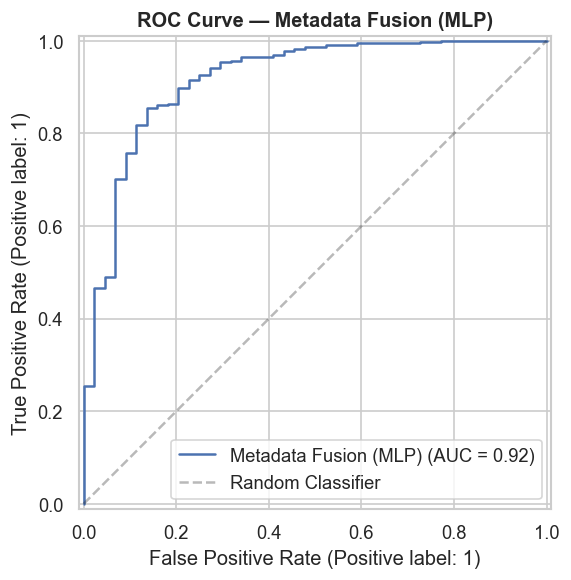

In [33]:
# --------------- ROC CURVE ---------------
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_test_proba, name=best_model_name, ax=ax)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random Classifier')
ax.set_title(f'ROC Curve — {best_model_name}', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../../reports/fusion/best_model_roc.png', bbox_inches='tight')
plt.show()

**💾 Save Best Model & Results**

Persist the winning model and full results table for downstream use.

In [34]:
# --------------- SAVE MODEL & UPDATE REGISTRY ---------------

# Define model directory
model_dir = '../../models/fusion'

# Save the best model checkpoint
model_path = os.path.join(model_dir, 'best_fusion_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f"💾 Best model saved to: {model_path}")

# Save model metadata for reference
model_metadata = {
    'model_name': best_model_name,
    'strategy': strategy_name,
    'classifier': clf_type.upper(),
    'test_accuracy': float(accuracy_score(y_test, y_test_pred)),
    'test_precision': float(precision_score(y_test, y_test_pred)),
    'test_recall': float(recall_score(y_test, y_test_pred)),
    'test_f1': float(f1_score(y_test, y_test_pred)),
    'test_auc': float(roc_auc_score(y_test, y_test_proba)),
    'uses_metadata': uses_metadata,  
    'training_samples': len(y_train),
    'validation_samples': len(y_val),
    'test_samples': len(y_test)
}

metadata_path = os.path.join(model_dir, 'best_model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(model_metadata, f, indent=2)
print(f"📋 Model metadata saved to: {metadata_path}")

💾 Best model saved to: ../../models/fusion\best_fusion_model.pkl
📋 Model metadata saved to: ../../models/fusion\best_model_metadata.json


In [35]:
# Update champion model registry
if uses_metadata:
    y_val_pred = best_model.predict(X_img_val, X_text_val, metadata=metadata_val)
else:
    y_val_pred = best_model.predict(X_img_val, X_text_val)

val_acc_best = float(accuracy_score(y_val, y_val_pred))
val_f1_best = float(f1_score(y_val, y_val_pred))

update_registry(
    name=f"Fusion - {best_model_name}",
    arch="TraditionalFusion",
    rel_path="models/fusion/best_fusion_model.pkl",
    val_accuracy=val_acc_best,
    val_f1=val_f1_best,
    test_accuracy=model_metadata['test_accuracy'],
    test_f1=model_metadata['test_f1'],
    test_auc=model_metadata['test_auc'],
    img_dim=X_img_train.shape[1],
    text_dim=X_text_train.shape[1],
    num_classes=2
)

🏆  'Fusion - Metadata Fusion (MLP)' is the new best model!
   Fusion - Metadata Fusion (MLP) (0.9448) → Fusion - Metadata Fusion (MLP) (0.9462)
   Registry: c:\Users\SAFAE ERAJI\Desktop\M2\Stage PFE\multimodal_fake_news_detection\models\best_model.json


True

In [36]:
# --------------- SAVE RESULTS TABLE ---------------
results_path = '../../reports/fusion/fusion_results.csv'
df_results.to_csv(results_path, index=False)
print(f"📊 Results table saved to: {results_path}")

📊 Results table saved to: ../../reports/fusion/fusion_results.csv


In [37]:
# --------------- SAVE TEST PREDICTIONS ---------------
test_predictions = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_test_pred,
    'y_proba_fake': y_test_proba
})

preds_path = '../../data/predictions/fusion_test_predictions.csv'
test_predictions.to_csv(preds_path, index=False)
print(f"📋 Test predictions saved to: {preds_path}")

print(f"\n{'='*60}")
print(f"✅ Pipeline complete! Best strategy: {best_model_name}")
print(f"   F1-Score: {best['F1-Score']:.4f} | ROC-AUC: {best['ROC-AUC']:.4f}")
print(f"{'='*60}")

📋 Test predictions saved to: ../../data/predictions/fusion_test_predictions.csv

✅ Pipeline complete! Best strategy: Metadata Fusion (MLP)
   F1-Score: 0.9741 | ROC-AUC: 0.9041
